<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>Estatística para Ciência de Dados</b></CENTER>
        <CENTER><b>Estratificação amostral da população</b></CENTER><br/>

# Estratificação amostral da população

**OBJETIVO GERAL:** Aplicar técnicas estatísticas para análisar e validar a **acurácia e precisão** (qualidade) das amostras sobre a população.

**SUMÁRIO:**

1.   Conceito de **Inferência Estatística** versus **Aprendizado de Máquina**

1.   Intervalo de confiança e Erro-Padrão

1.   Análise Bootstrap

1. Erro Padrão Médio

1. Intervalo de Confiança

1. Tamanho "IDEAL" da amostra

# BIBLIOTECAS E FUNÇÕES:

In [ ]:
# Estruturação dos Dados: NDArray / Pandas
import pandas as pd
import numpy as np

# Inferência Estatística x Aprendizado de Máquina
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import bootstrap
from sklearn.datasets import fetch_california_housing

# Visualização dos Dados
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def statistic(_dataset):
    """
      Compute descriptive statistics for a numerical dataset.

      This function extends the standard pandas `describe()` method
      by removing the count metric and adding:
      - Range (max - min)
      - Mode

      The output is a table of descriptive statistics commonly used
      in Exploratory Data Analysis (EDA).

      Parameters
      ----------
      _dataset : pandas.Series or pandas.DataFrame
          Input dataset containing numerical values.

      Returns
      -------
      pandas.DataFrame
          A DataFrame with descriptive statistics (excluding count),
          including range and mode, sorted and rounded to two decimals.
    """

    # Generate basic descriptive statistics using pandas
    # (count, mean, std, min, quartiles, and max)
    _describe = _dataset.describe()

    # Remove the 'count' row, as it is not used in this analysis
    _describe = _describe.drop('count')

    # Compute the range for each numerical column
    # Range = maximum value minus minimum value
    _describe.loc['range'] = _describe.loc['max'] - _describe.loc['min']

    # Compute the mode for each numerical column
    # stats.mode returns both mode and frequency;
    # [0] extracts only the modal value
    _describe.loc['mode'] = stats.mode(
        _dataset,
        keepdims=False,
        nan_policy='omit'
    )[0]

    # Sort the statistics (index) and round all values to two decimal places
    _describe = np.around(_describe.sort_values(), 2)

    # Return the final descriptive statistics table
    return _describe

In [ ]:
def PlotarStatistic(dataset, yLabel=None):
    """
      Plot descriptive statistics of a dataset and highlight
      measures of central tendency (mean, median, and mode).

      This function computes descriptive statistics using a
      previously defined `statistic()` function, generates
      a plot with summary measures, and prints the numerical
      descriptive table.

      Parameters
      ----------
      dataset : pandas.Series or pandas.DataFrame
          Input dataset containing numerical values.
          It is expected that the statistic() function
          can process this object.

      yLabel : str, optional
          Label for the y-axis of the plot.

      Returns
      -------
      None
          Displays a plot and prints descriptive statistics.
    """

    # Compute descriptive statistics using a custom function
    _describe = statistic(dataset)

    # -------------------------------------------------------
    # Construction of LaTeX-formatted labels for statistics
    # -------------------------------------------------------

    # Mean (population notation: overline mu)
    # Raw string (r'') avoids invalid escape sequence warnings
    mean_mu = r'MÉDIA:  $\overline{\mu}$ = '
    mean_mu += f'{_describe["mean"]: .2f}'  # Numeric value formatted to 2 decimals

    # Median (tilde mu)
    median_mu = r'MEDIANA: $\tilde{\mu}$ = '
    median_mu += f'{_describe["50%"]: .2f}'

    # Mode (hat mu)
    mode_mu = r'MODA: $\hat{\mu}$ = '
    mode_mu += f'{_describe["mode"]: .2f}'

    # New line separator for legend text composition
    enter = '\n'

    # Concatenated label containing all summary measures
    label = mean_mu + enter + median_mu + enter + mode_mu

    # -------------------------------------------------------
    # Plotting section
    # -------------------------------------------------------

    # Apply the statistic function as an aggregation and plot the result
    # (Assumes dataset supports aggregation and plotting)
    dataset.agg(statistic).plot(
        figsize=[15, 6],
        label='MEDIDAS DE RESUMO: '
    )

    # Plot the mean marker at its corresponding index position
    plt.plot(
        list(_describe.index).index('mean'),
        _describe["mean"],
        'D',
        label=mean_mu
    )

    # Plot the median marker
    plt.plot(
        list(_describe.index).index('50%'),
        _describe["50%"],
        'D',
        label=median_mu
    )

    # Plot the mode marker
    plt.plot(
        list(_describe.index).index('mode'),
        _describe["mode"],
        'D',
        label=mode_mu
    )

    # Set plot title
    plt.title('ESTATÍSTICA DESCRITIVA DO DATASET')

    # Display legend with statistical labels
    plt.legend()

    # Set y-axis label if provided
    plt.ylabel(yLabel)

    # Render the plot
    plt.show()

    # -------------------------------------------------------
    # Textual output
    # -------------------------------------------------------

    # Print descriptive statistics table
    print('ESTATÍSTICA DESCRITIVA DO DATASET:')
    print(_describe)

In [ ]:
def bootstrap_distribution_eda(data, metric=np.mean, bins=30, confidence_level=0.90):
    """
    Compute and visualize the bootstrap sampling distribution of a statistic
    using Seaborn for advanced Exploratory Data Analysis (EDA).

    Parameters
    ----------
    data : array-like
        One-dimensional numeric sample.

    metric : callable, default=np.mean
        Statistic applied to each bootstrap resample.

    bins : int, default=30
        Number of histogram bins.

    confidence_level : float, default=0.90
        Confidence level for the bootstrap interval.

    Returns
    -------
    res : BootstrapResult
        Object containing bootstrap distribution, CI, and standard error.
    """

    rng = np.random.default_rng()
    data = (data,)

    # Bootstrap computation
    res = bootstrap(
        data,
        metric,
        confidence_level=confidence_level,
        random_state=rng
    )

    dist = res.bootstrap_distribution

    # ---- Advanced Visualization with Seaborn ----
    plt.figure(figsize=(10, 6))

    # Histogram + KDE
    sns.histplot(dist, bins=bins, kde=True, stat="density")

    # Mean of bootstrap distribution
    plt.axvline(np.mean(dist), linestyle='-', label='Bootstrap Mean')

    # Confidence interval bounds
    plt.axvline(res.confidence_interval.low, linestyle='--', label='CI Lower')
    plt.axvline(res.confidence_interval.high, linestyle='--', label='CI Upper')

    plt.title("Bootstrap Sampling Distribution")
    plt.xlabel("Statistic Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    print("CONFIDENCE INTERVAL")
    print(f"LOW  : {res.confidence_interval.low:.4f}")
    print(f"HIGH : {res.confidence_interval.high:.4f}")
    print(f"SE   : {res.standard_error:.4f}")

    #return res

#$\mapsto$CONCEITOS BÁSICOS:

"...O campo da estatística lida com a coleta, apresentação, análise e uso dos dados para tomar decisões, resolver problemas e planejar produtos e processos. Em termos simples, **estatística é a ciência de dados**."

$\mapsto$**LIVRO 1:** **Estatística Prática para Cientistas de Dados: 50 conceitos essenciais**: [Link da MINHA BIBLIOTECA!](https://integrada.minhabiblioteca.com.br/reader/books/9788550813004/epubcfi/6/24%5B%3Bvnd.vst.idref%3DePub_Practical_Statistics_cap02%5D!/4%5BePub_Practical_Statistics_cap02%5D/4%5B_idContainer143%5D/2/1:0%5B%2CCap%5D)

$\mapsto$**LIVRO 2:** (C., MONTGOMERY, D. Estatística Aplicada e Probabilidade para Engenheiros: Grupo GEN, 2021. 9788521637448. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9788521637448/. Acesso em: 06 fev. 2022.)


## POPULAÇÃO versus AMOSTRA:

Os **dados** são quase sempre uma **amostra** que foi selecionada a partir de alguma **população**.

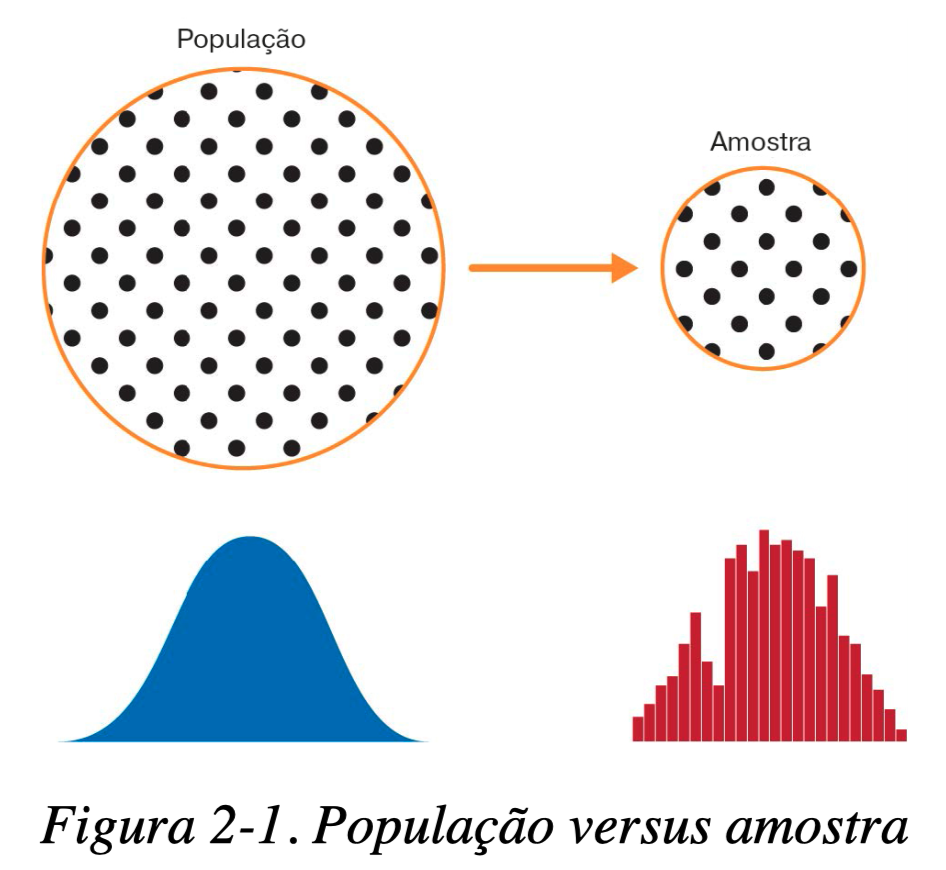

## INFERÊNCIA ESTATÍSTICA:

<CENTER>

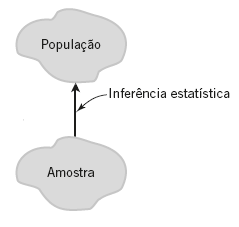

A **inferência estatística** é o processo de usar a análise de dados para inferir propriedades de uma distribuição de probabilidade subjacente.

$\mapsto$ A **análise estatística inferencial infere propriedades de uma população** , por exemplo, testando hipóteses e derivando estimativas. Supõe-se que o conjunto de dados observado é amostrado de uma população maior.

A **estatística inferencial** pode ser contrastada com a estatística descritiva . A **estatística descritiva** se preocupa apenas com as propriedades dos dados observados e não se baseia na suposição de que os dados vêm de uma população maior.

$\mapsto$**No aprendizado de máquina , o termo inferência às vezes é usado para significar "fazer uma previsão, avaliando um modelo já treinado"**; neste contexto, inferir propriedades do modelo é referido como treinamento ou aprendizado (em vez de inferência ), e usar um modelo para previsão é referido como inferência (em vez de previsão).

(**Citação**: [Link](https://en.wikipedia.org/wiki/Statistical_inference))

#$\mapsto$INFERÊNCIA ESTATÍSTICA versus APRENDIZADO DE MÁQUINA:

🎓 Explicação Didática:

*   **Statistical Learning** é usado quando o interesse está em "por que isso acontece?", buscando compreender causalidade ou associação.
*   **Machine Learning**, por outro lado, responde "o que vai acontecer?", sendo ideal para problemas preditivos onde a explicação é menos relevante que a acurácia.

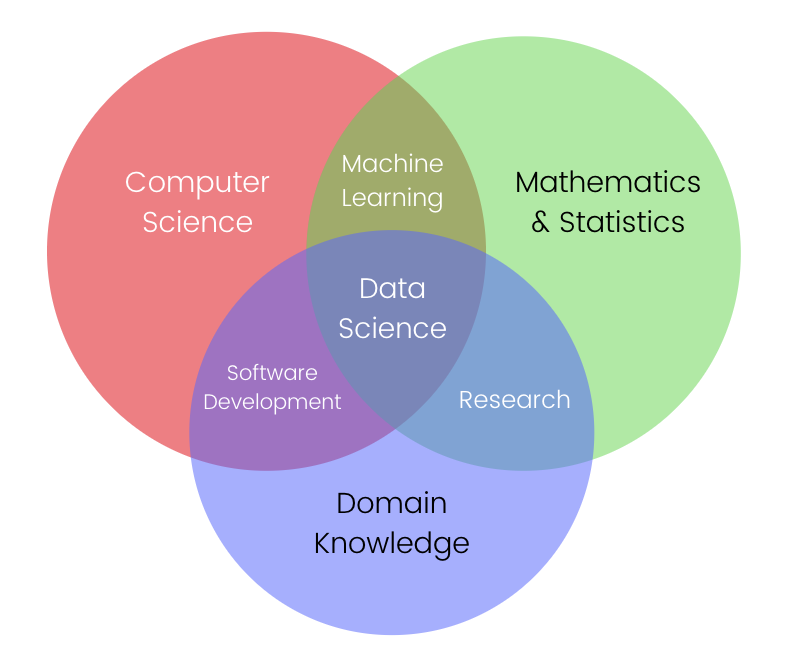

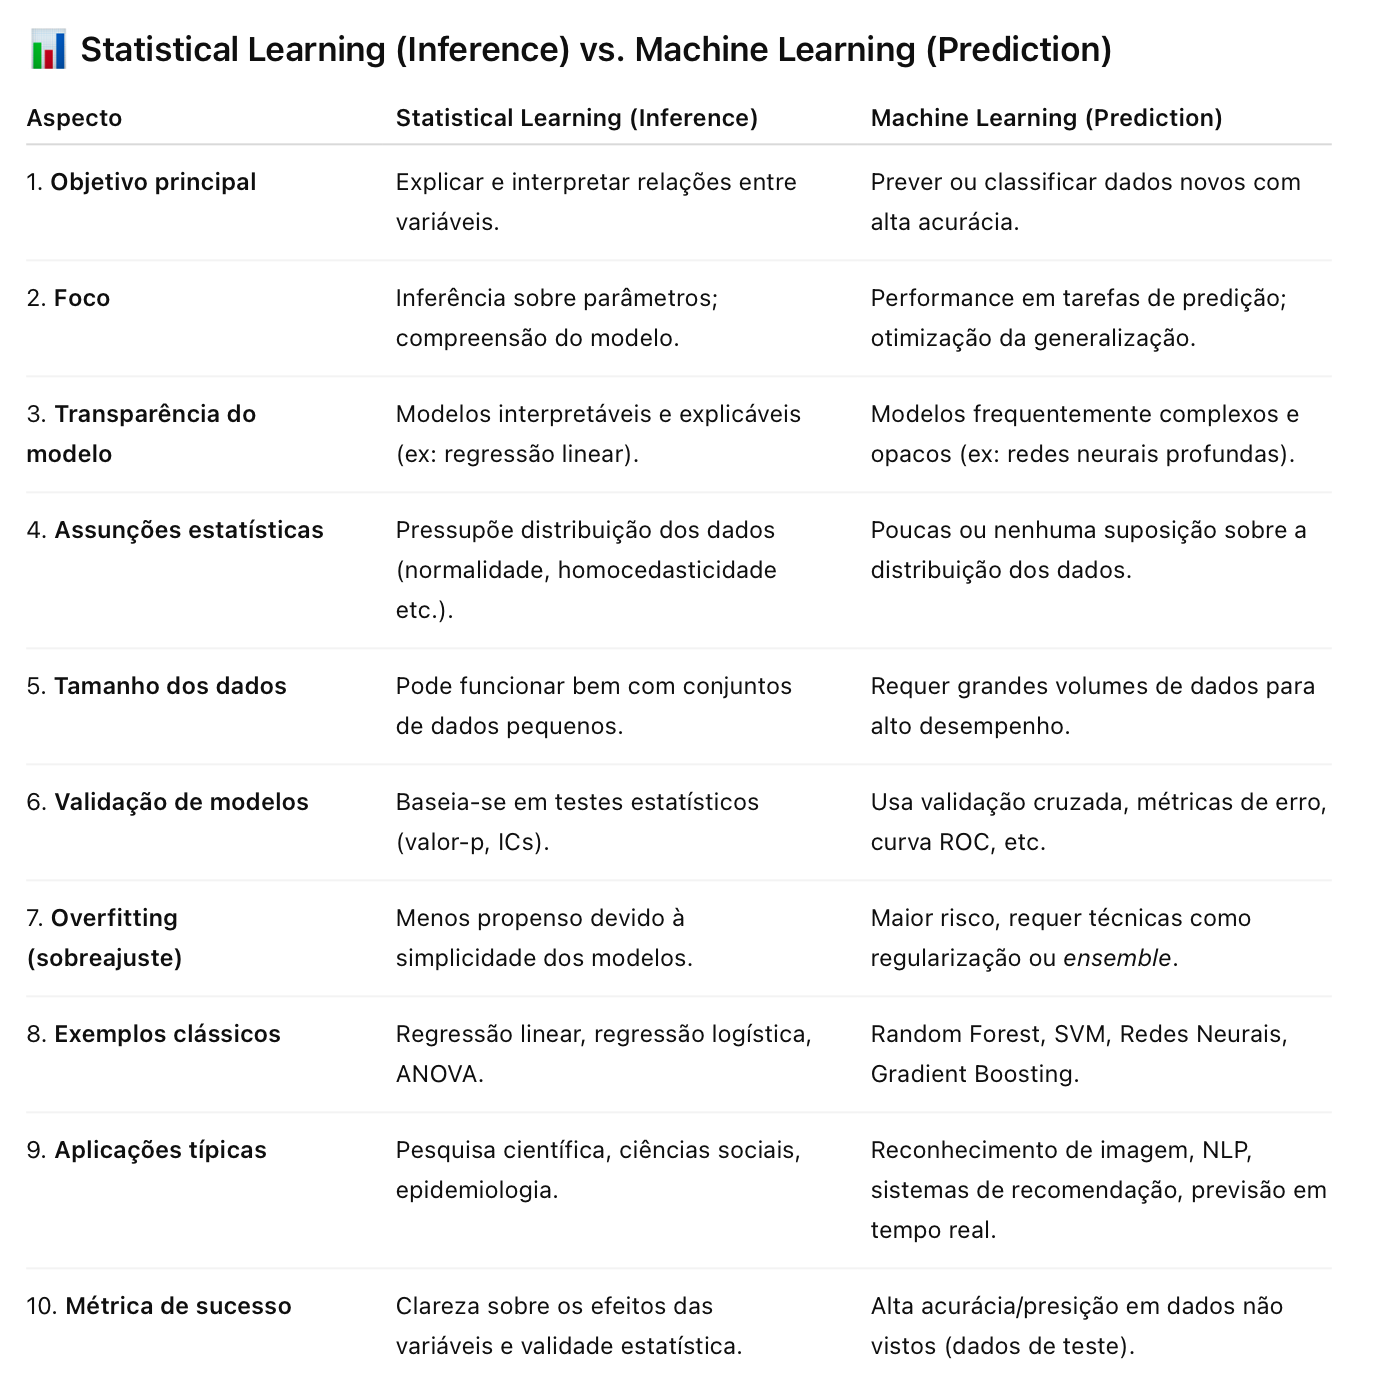

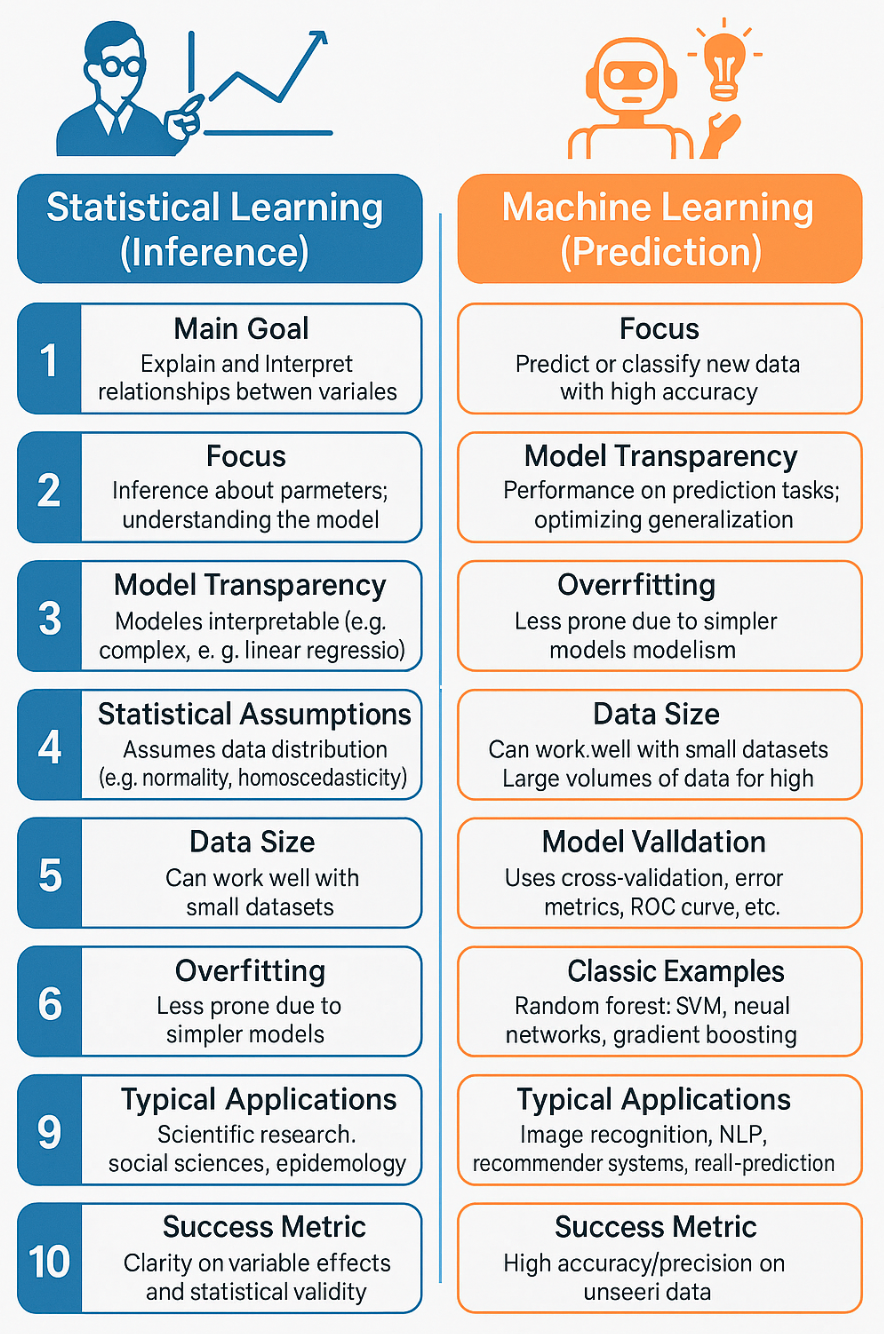

## 📊 Statistical Learning vs 🤖 Machine Learning

<center>

**Quanto custa uma casa ?**

<center>

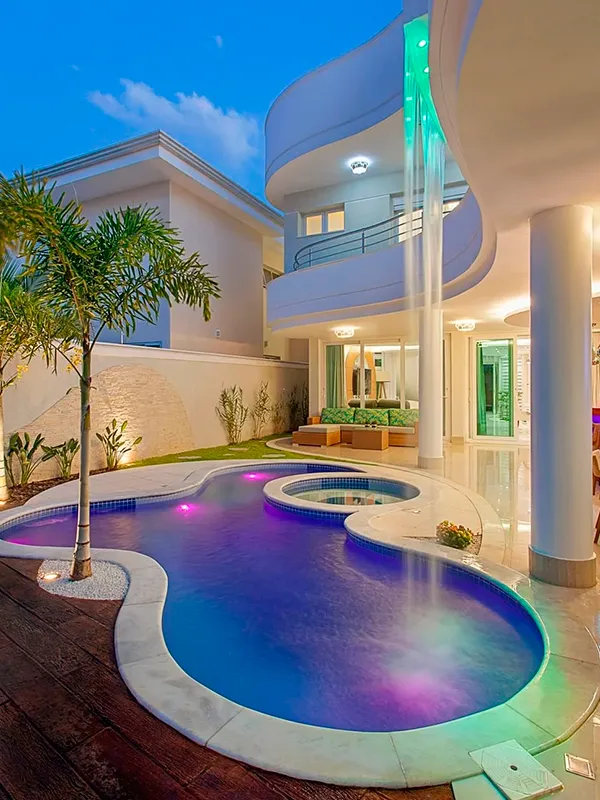

O custo de uma casa varia muito, dependendo de diversos fatores, como localização, tamanho, materiais de construção e acabamento. Em média, o custo para construir **uma casa no Brasil pode variar de R\$ 1.700 a R\$ 2.000 por metro quadrado**.

Fatores que influenciam o custo:
*   **Localização**: O valor do terreno e os custos de construção podem variar bastante entre diferentes regiões e cidades.
*   **Tamanho**: Casas maiores naturalmente terão um custo de construção mais elevado.
*   **Materiais de construção**: A escolha dos materiais (tijolos, cimento, pisos, revestimentos, etc.) afeta diretamente o custo final.
*   **Acabamento**: Nível de acabamento (simples, médio, alto padrão) também influencia o valor.
*   **Mão de obra**: A contratação de profissionais qualificados pode ter um custo mais elevado.
*   entre outras inúmeras variáveis.....

Exemplo com **Regressão Linear** usando o dataset California Housing

<center>

**MODELO DE REGRESSÃO LINEAR:**

$y = \beta X + \epsilon$

Sendo que:


*   **VARIÁVEL DEPENDENTE - SAÍDA**: $y$

*   **VARIÁVEL INDEPENDENTE - DADOS DE ENTRADA**: $X$: $[x_1, x_2, ..., x_n]$

*   $\beta$: Coeficientes de $X$: $[\beta_1, \beta_2, ..., \beta_n]$ + $\beta_0$

*   $\beta_0$: Ponto de intercessão.

*   $\epsilon$: Erro aleatório (sem viés) + Média: $\mu = 0$ + Desvio Padrão: $\sigma = 1$

In [ ]:
# Carregar dados
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['PRICE'] = data.target # y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 📈 1. Statistical Learning com `statsmodels`
- Foco em interpretação dos coeficientes

In [ ]:
X = df[['AveRooms']]
y = df['PRICE']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     487.8
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          7.57e-107
Time:                        01:21:14   Log-Likelihood:                -32001.
No. Observations:               20640   AIC:                         6.401e+04
Df Residuals:                   20638   BIC:                         6.402e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6838      0.019     87.952      0.0

📌 Interpretação:
*   O **coef**: $X$: $[\beta_1 = 0.0709]$ + $\beta_0 = 1.6838$ da variável AveRooms mostra o efeito **médio no preço** por cada unidade adicional no número de cômodos.
*   O **p-value** indica se o coeficiente é estatisticamente significativo.

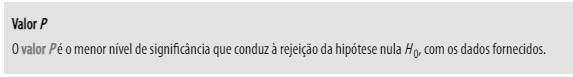

## 🤖 2. Machine Learning com `scikit-learn`
- Foco em predição e erro

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_ml = df[['AveRooms']]
y_ml = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.3, random_state=42)

ml_model = LinearRegression()
ml_model.fit(X_train, y_train)
y_pred = ml_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro quadrático médio (MSE): {mse:.2f}")

Erro quadrático médio (MSE): 1.28


📌 Interpretação:

* Aqui não nos importamos com significância estatística, mas sim com o desempenho preditivo, medido pelo MSE.

### Resumo:

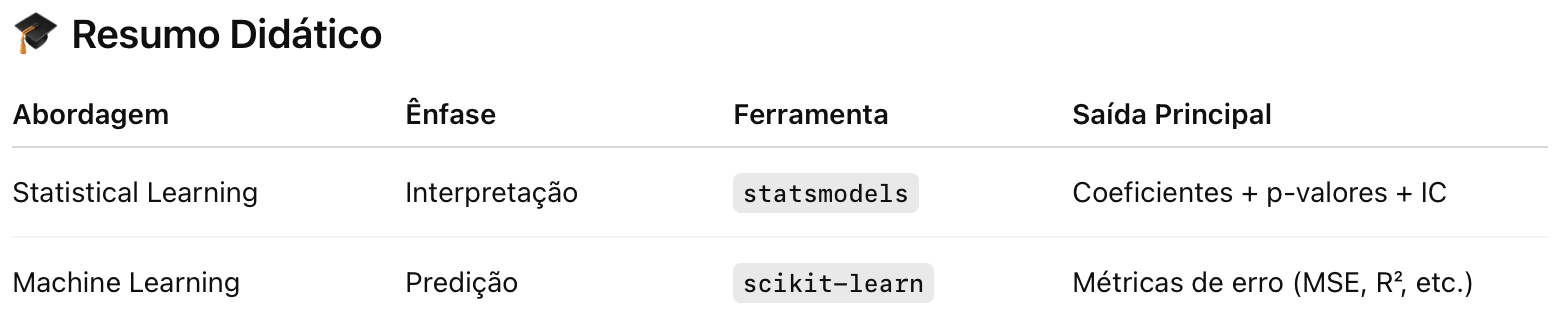

##Aprofundando no problema:

<center> " ... o tempo não para... "

<center>

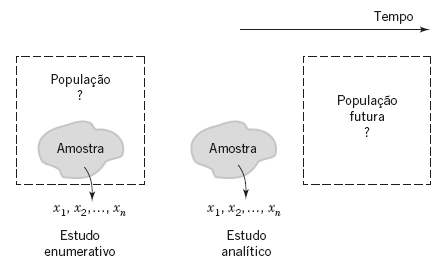

<center>

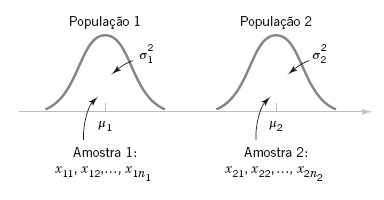

A **Inferência Estatística** pode ser dividida em duas áreas principais:

* **Estimativa de parâmetros**: População (Média Real: $\mu$) x Amostra (Média Amostral: $\hat\mu$);
* **Teste de Hipóteses**.

<center>

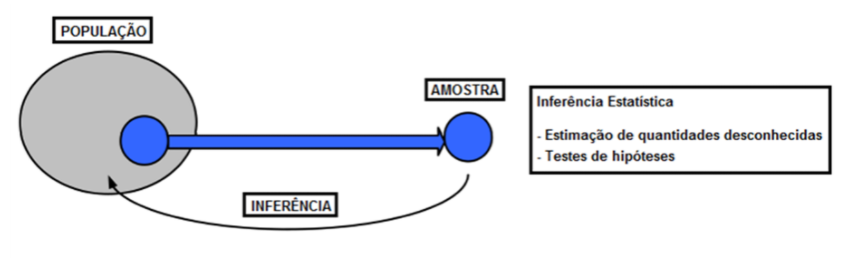

A **Média Amostral** ($\hat\mu$) é uma estatística; ou seja, é uma **variável aleatória** que depende dos **resultados obtidos em cada amostra em particular**. Como uma **estatística é uma variável  aleatória**, ela possui uma **Distribuição de Probabilidade**.

<center>

<font size="5">**Média Amostral**: ${\hat\mu}$ = $\frac{x_1 + x_2 + x_3 + ... + x_n}{n}$</font>

<center>

**Distribuição de Probabilidade**.

<center>

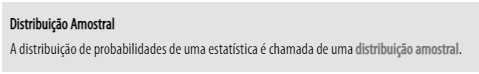

##Estimativa de parâmetros:

### Tipos de variáveis

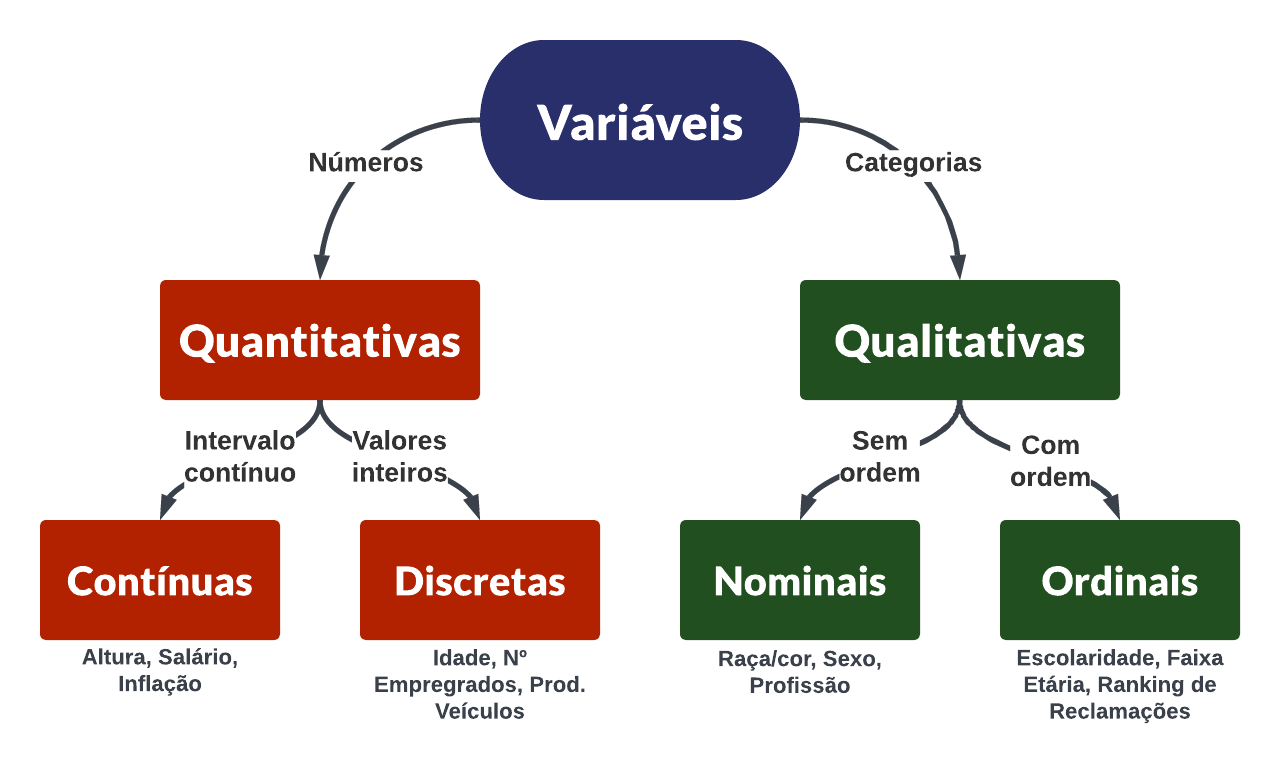

### Técnicas da Estatística Descritiva de Dados

<FONT COLOR="#0000AA"><font size="5"> <center> <b>Principais Técnicas da Estatística Descritiva de Dados

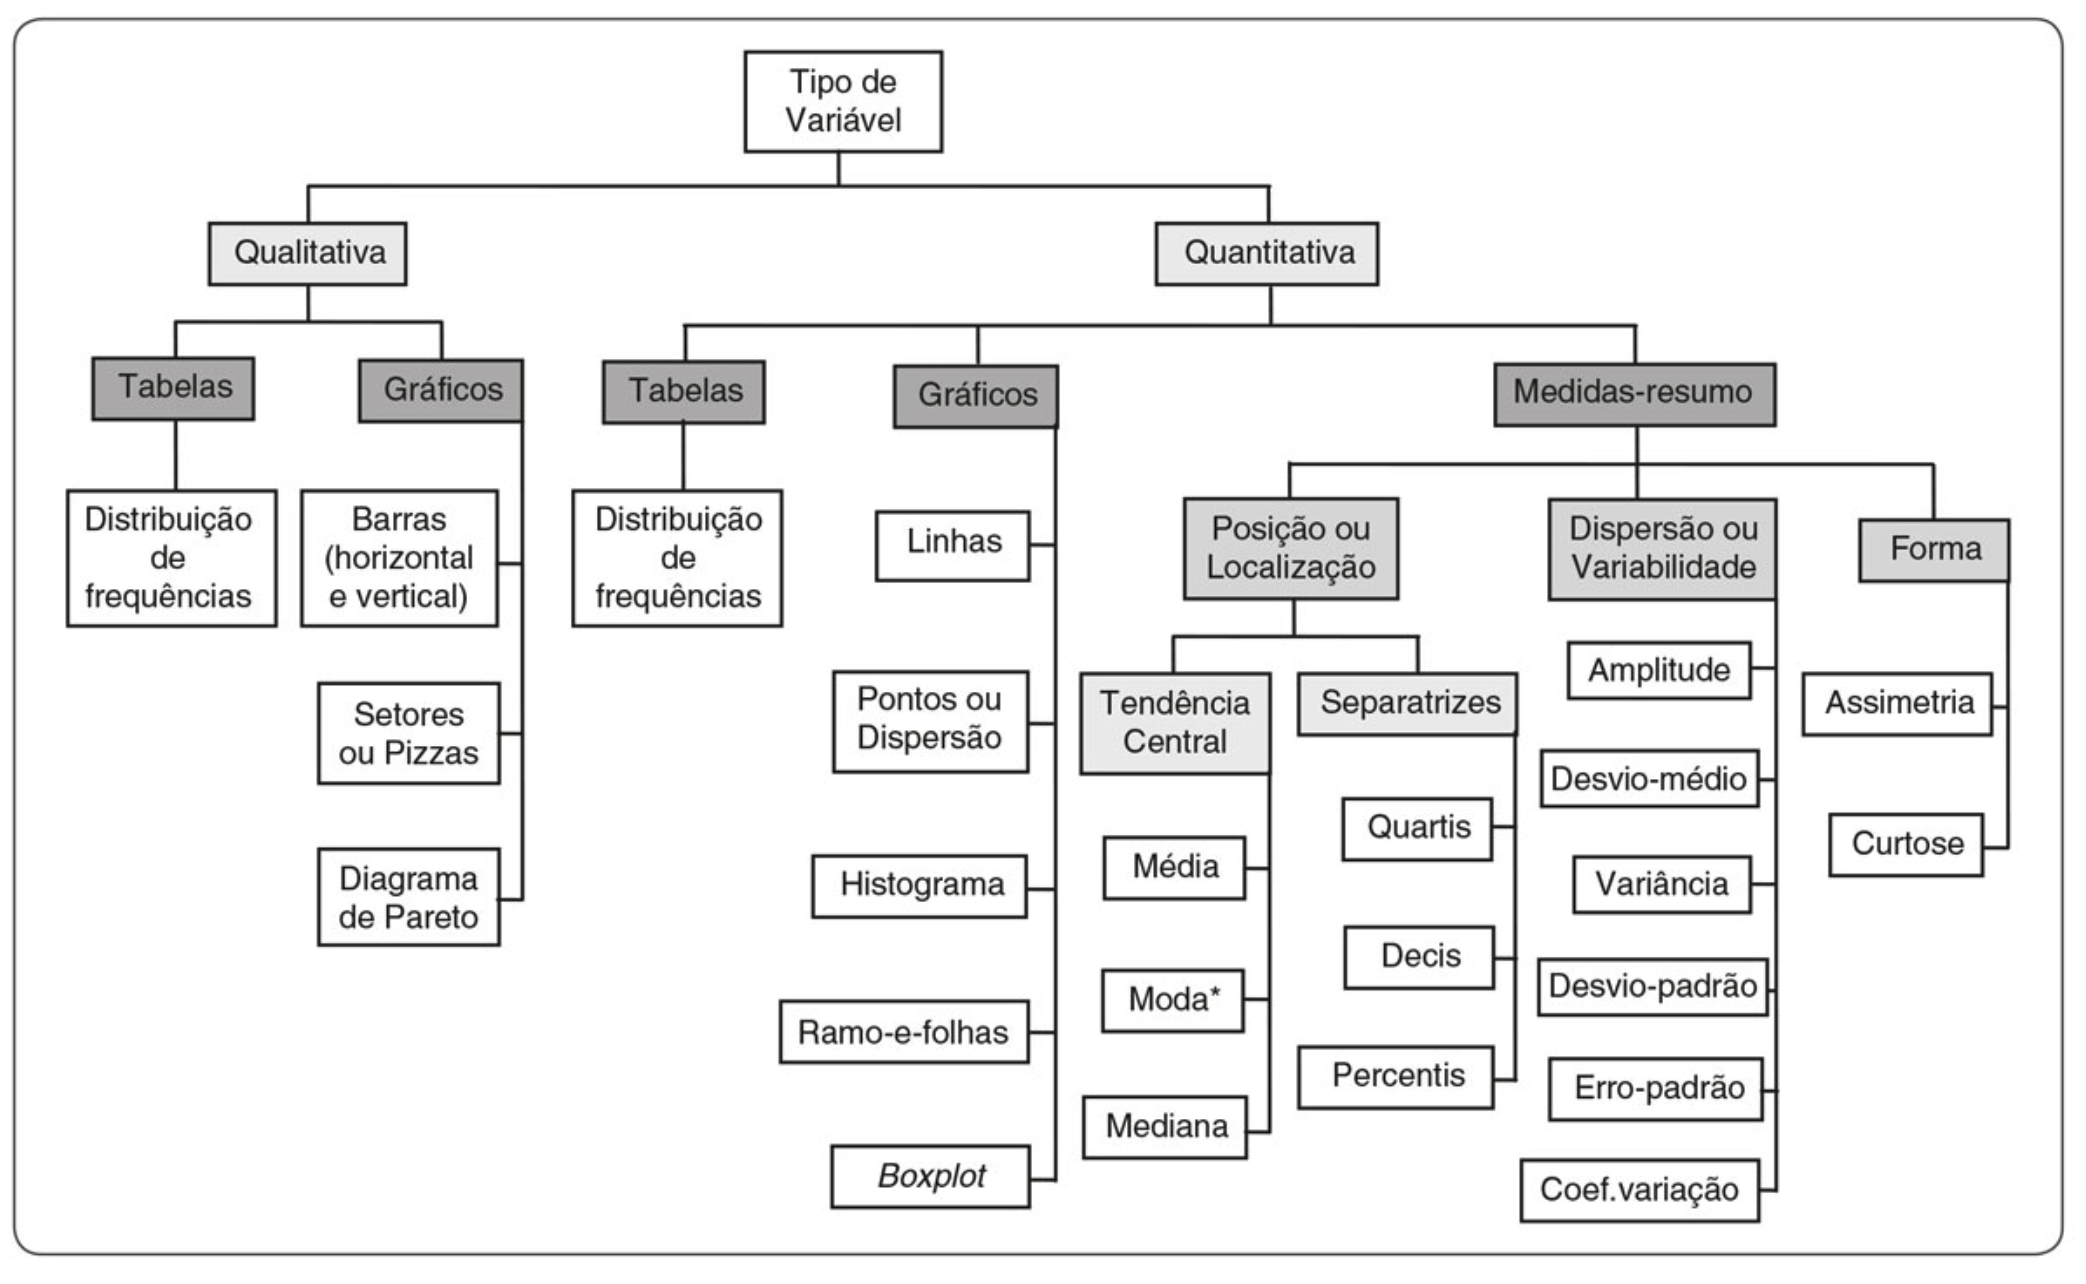

#$\mapsto$Análise **BOOTSTRAP**

Referência Bibliográfica: [Link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)

## Central Limit Theorem

<center>

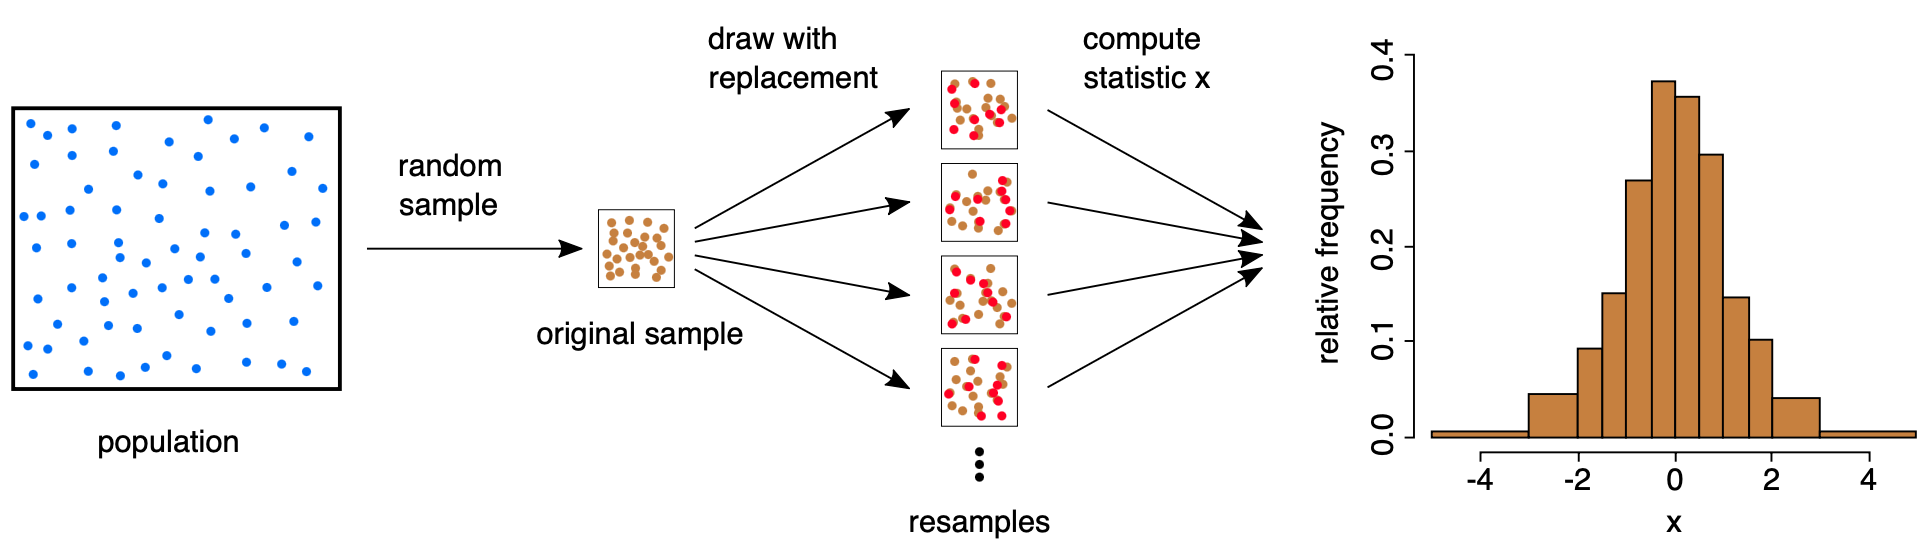

##Intervalo de Confiança

Uma **estimativa de intervalo para um parâmetro de uma população** é chamada de **intervalo de confiança**.

*   Informação sobre a precisão de estimação é expressa pelo **comprimento do intervalo (%)**.

Um intervalo curto implica estimação precisa. Não podemos estar certos de que o intervalo contém o parâmetro verdadeiro desconhecido da população ‒ usamos somente uma amostra proveniente da população completa para calcular a estimativa pontual e o intervalo.

No entanto, o **intervalo de confiança é construído de modo que tenhamos alta confiança de que ele contenha o parâmetro desconhecido da população**. Intervalos de confiança são largamente utilizados em engenharia e nas ciências.

<center>

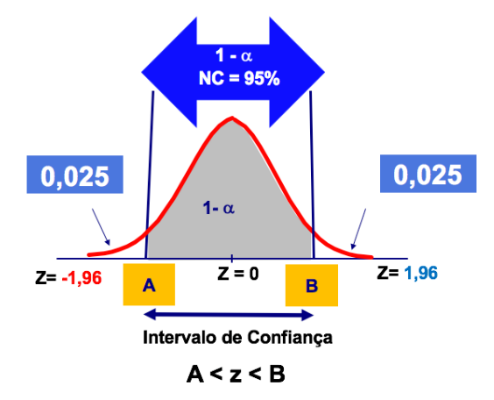

## Erro-Padrão

Referencia Bibliográfica: [Link](https://integrada.minhabiblioteca.com.br/reader/books/9788550813004/epubcfi/6/24%5B%3Bvnd.vst.idref%3DePub_Practical_Statistics_cap02%5D!/4%5BePub_Practical_Statistics_cap02%5D/4%5B_idContainer143%5D/270/2)

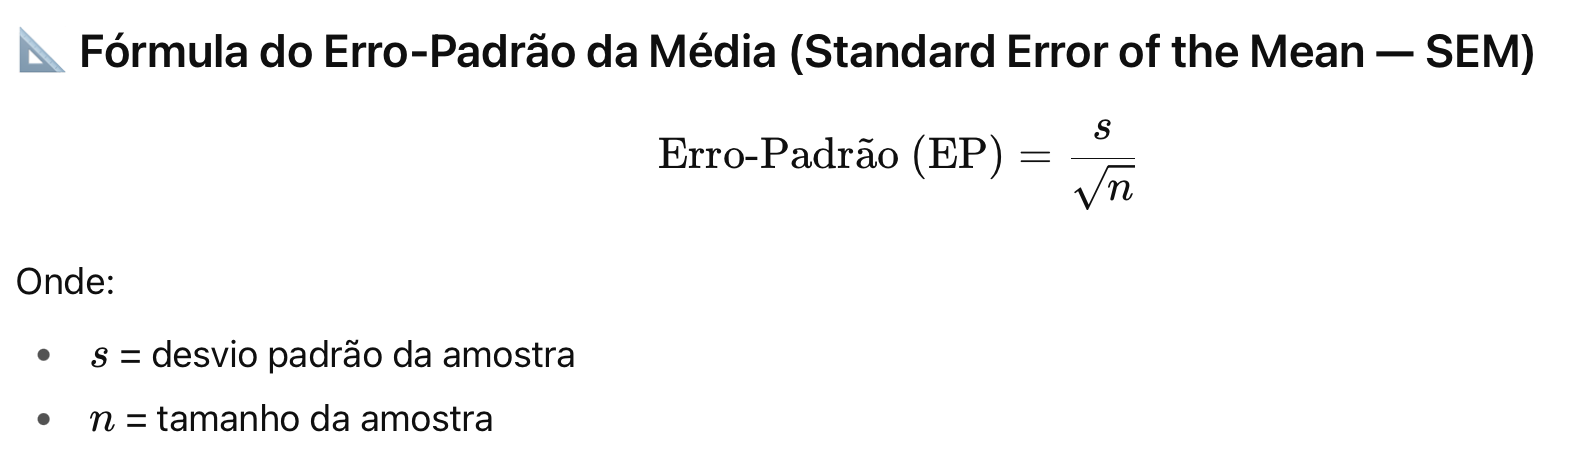

In [ ]:
def SE(dataset):
  '''
    HELP: Standart Error (Erro Padrão)
    O Erro-Padrão é uma métrica única que resume a variabilidade na distribuição de amostragem para uma estatística.
    Ele pode ser estimado utilizando uma estatística baseada no desvio-padrão (Sigma) dos valores da amostra e no tamanho de amostra N:
  '''
  return dataset.std() / (len(dataset) ** 0.5)

## Tamanho versus Qualidade: Qual o tamanho "ideal" da amostra?

<center>

**Qual é o gasto médio no supermercado ?**

<center>

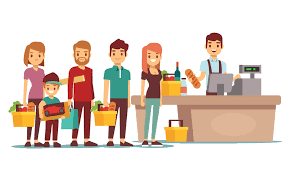

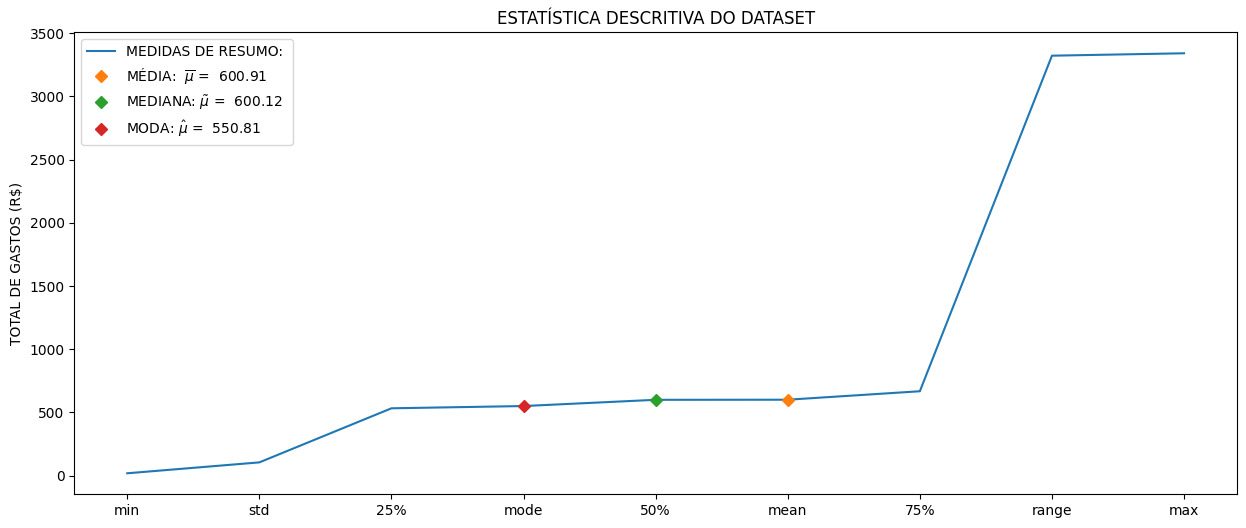

ESTATÍSTICA DESCRITIVA DO DATASET:
min        19.00
std       105.16
25%       532.99
mode      550.81
50%       600.12
mean      600.91
75%       667.87
range    3322.15
max      3341.15
Name: TOTAL DE GASTOS (R$), dtype: float64


In [ ]:
def createTable(size = 200_000, mean = 1_000.00, std = 100.00, outliers = 100):
  table = pd.DataFrame({'NOTA FISCAL': np.random.choice(np.arange(10_000, 250_000), size, replace=False),
                      'SALÁRIO BRUTO (R$)': np.around(np.random.normal(mean * 2, std, size), 2),
                      'TOTAL DE GASTOS (R$)': np.zeros(size)})
  table.iloc[:199900, 2] = np.around(np.random.normal(0.60 * mean, std, size - outliers), 2)
  table.iloc[199900:, 2] = np.around(np.random.randint(2, 3555, outliers) * 0.95, 2) # Erro aleatório
  return table
table = createTable()
PlotarStatistic(table['TOTAL DE GASTOS (R$)'], yLabel = 'TOTAL DE GASTOS (R$)')

<Axes: ylabel='TOTAL DE GASTOS (R$)'>

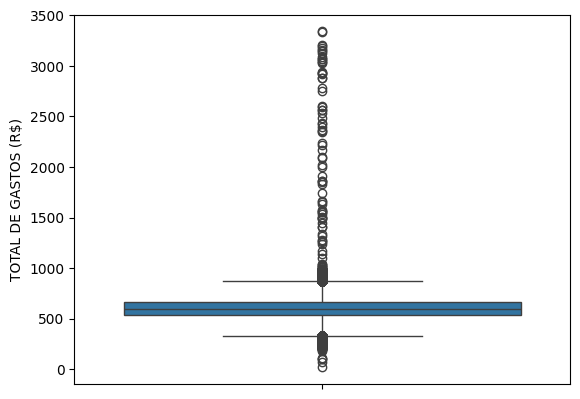

In [ ]:
sns.boxplot(table['TOTAL DE GASTOS (R$)'])

## Distribuição Amostral

Referência Bibliográfica: [Link](https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.stats.bootstrap.html)

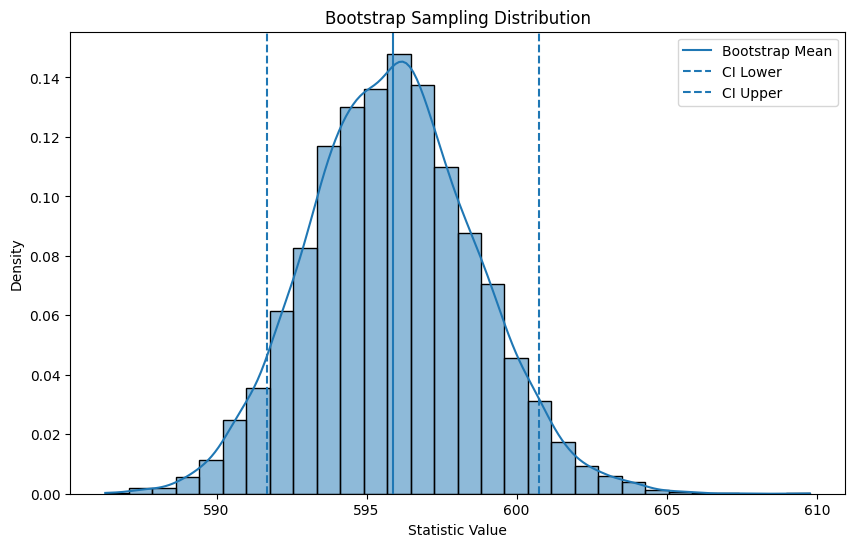

CONFIDENCE INTERVAL
LOW  : 591.6665
HIGH : 600.7332
SE   : 2.7634


In [ ]:
bootstrap_distribution_eda(table.sample(n=2_000, replace=False)['TOTAL DE GASTOS (R$)'])

## Gráfico do Erro-Padrão Médio: **Tamanho Ideal** da amostra

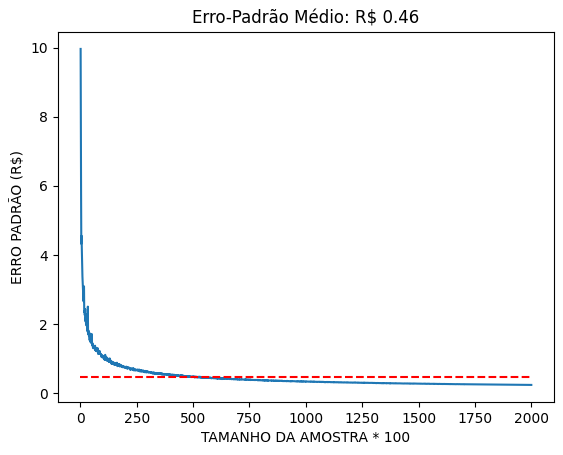

In [ ]:
array_se = np.zeros(2000, dtype=float)
j = 0
for i in range(100, 200_100, 100):
  tb = table.sample(n = i, replace = False)['TOTAL DE GASTOS (R$)']
  array_se[j] = SE(tb)
  j += 1
x = np.arange(1, 2001, 1)
y = array_se
plt.plot(x, y)
plt.title(f"Erro-Padrão Médio: R${np.mean(array_se): .2f}")
plt.ylabel('ERRO PADRÃO (R$)')
plt.xlabel('TAMANHO DA AMOSTRA * 100')
plt.hlines(np.mean(array_se), 0, 2000, colors='red', linestyles = '--')
plt.show()

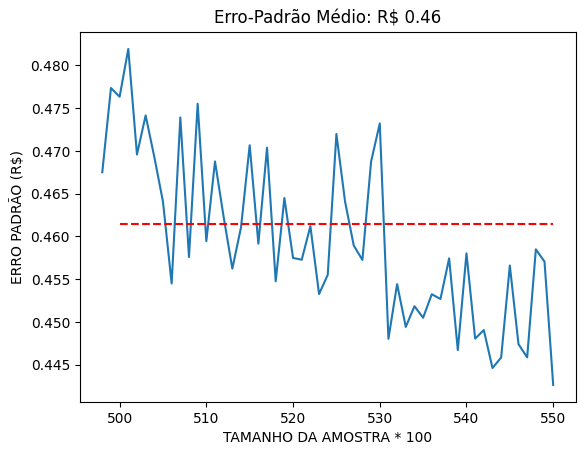

In [ ]:
plt.plot(x[497:550], y[497:550])
plt.title(f"Erro-Padrão Médio: R${np.mean(array_se): .2f}")
plt.ylabel('ERRO PADRÃO (R$)')
plt.xlabel('TAMANHO DA AMOSTRA * 100')
plt.hlines(np.mean(array_se), 500, 550, colors='red', linestyles = '--')
plt.show()

# Conclusões:

🎓 Em resumo:
*   ❌ Não há um valor “correto” ou “ideal” universal para o erro-padrão.
*   ✅ O que importa é interpretar seu valor relativo ao tamanho da amostra e à variabilidade dos dados.
*   ✅ No exemplo, o SE (erro-padrão) está se estabilizando em torno de R$ 0.46
*   ✅ Com isso, o tamanho (“correto” ou “ideal”) da amostra está entre ~ 50.000 e ~ 55.000 notas fiscais.

Em inferência estatística, **menor erro-padrão geralmente indica uma estimativa mais confiável da média**.

🔍 Interpretação conjunta com distribuição normal:

Se os dados forem normalmente distribuídos, o erro-padrão nos ajuda a:
*   Construir intervalos de confiança da média
*   Avaliar o quanto a média da amostra se afasta da média populacional
* Aplicar testes de hipóteses para validar as decisões sobre o **Tamanho x Qualidade da Amostra**.

#$\mapsto$**EXERCÍCIOS DE FIXAÇÃO:**

Sobre o **DATASET: [aqui](https://drive.google.com/file/d/1-X0q7OpvGmr8HQpXcaxUkGuz3wdMIC-U/view?usp=sharing)**, faça:

##QUESTÃO 1

<center>

**Quanto custa um vinho ?**

Determinar o tamanho da amostra por:

Fazer os cálculos / Gráficos, sobre a variável PREÇO DO VINHO (R$) para determinar:
*   Erro-Padrão Médio por CLASSIFICAÇÃO POR TEMPO: JOVEM, RESERVA ou GRAN RESERVA.
*   Intervalo de Confiança por CLASSIFICAÇÃO POR TEMPO: JOVEM, RESERVA ou GRAN RESERVA.
*   Gráfico da Análise Bootstrap CLASSIFICAÇÃO POR TEMPO: JOVEM, RESERVA ou GRAN RESERVA.

In [ ]:
# CLASSIFICAÇÃO POR TEMPO = ['JOVEM', 'RESERVA', 'GRAN RESERVA']
# CLASSIFICAÇÃO POR TEMPO = [1, 2, 3]

In [ ]:
table = pd.read_csv('/content/table.csv', index_col=0)

y = 'PREÇO DO VINHO (R$)'
x = 'CLASSIFICAÇÃO POR TEMPO'

In [ ]:
table.head(3)

,index,NOTA FISCAL,CLASSIFICAÇÃO POR TEMPO,PREÇO DO VINHO (R$)
0,48467,162106,1,690.70
1,104577,37763,1,480.52
2,150035,62571,1,569.08


In [ ]:
table.shape

(200000, 4)

In [ ]:
table['CLASSIFICAÇÃO POR TEMPO'] = table['CLASSIFICAÇÃO POR TEMPO'].map({
    1: 'JOVEM',
    2: 'RESERVA',
    3: 'GRAN RESERVA'
})

In [ ]:
def analisePrecoVinho(
    table: pd.DataFrame,
    yLabel: str = None,
    Qualitativa: str = None,
    confidence: float = 0.95,
    n_resamples: int = 2000
    ) -> pd.DataFrame:
    """
    Calcula, por classe de uma variável qualitativa:
    erro-padrão médio, intervalo de confiança da média
    e gráfico bootstrap da média.

    Args:
        table (pd.DataFrame): Dataset de entrada.
        yLabel (str): Variável quantitativa de interesse.
        Qualitativa (str): Variável qualitativa para agrupamento.
        confidence (float): Nível de confiança.
        n_resamples (int): Número de reamostragens bootstrap.

    Returns:
        pd.DataFrame: Tabela resumo com n, média, erro-padrão e IC.
    """

    if yLabel is None:
        raise ValueError("Informe a variável quantitativa em yLabel.")

    if Qualitativa is None:
        raise ValueError("Informe a variável qualitativa em Qualitativa.")

    if yLabel not in table.columns:
        raise ValueError(f"A coluna '{yLabel}' não existe no DataFrame.")

    if Qualitativa not in table.columns:
        raise ValueError(f"A coluna '{Qualitativa}' não existe no DataFrame.")

    dados = table[[Qualitativa, yLabel]].dropna().copy()

    resultados = []

    classes = dados[Qualitativa].unique()

    for classe in classes:
        subset = dados[dados[Qualitativa] == classe][yLabel]

        n = subset.shape[0]
        media = subset.mean()
        desvio_padrao = subset.std(ddof=1)
        erro_padrao = desvio_padrao / np.sqrt(n)

        ic = stats.t.interval(
            confidence=confidence,
            df=n - 1,
            loc=media,
            scale=erro_padrao
        )

        boot = bootstrap(
            data=(subset.values,),
            statistic=np.mean,
            confidence_level=confidence,
            n_resamples=n_resamples,
            random_state=42,
            method='percentile'
        )

        resultados.append({
            'classe': classe,
            'n': n,
            'media': media,
            'erro_padrao': erro_padrao,
            'IC_inf': ic[0],
            'IC_sup': ic[1]
        })

        print(f'\n--- {classe} ---')
        print(f'Tamanho da amostra: {n}')
        print(f'Média: {media:.4f}')
        print(f'Erro-padrão: {erro_padrao:.4f}')
        print(f'IC {int(confidence*100)}%: ({ic[0]:.4f}, {ic[1]:.4f})')

        plt.figure(figsize=(7, 4))
        sns.histplot(boot.bootstrap_distribution, bins=30, kde=True)
        plt.axvline(media, linestyle='--', label='Média amostral')
        plt.axvline(boot.confidence_interval.low, linestyle=':', label='IC bootstrap')
        plt.axvline(boot.confidence_interval.high, linestyle=':')
        plt.title(f'Bootstrap da Média - {classe}')
        plt.xlabel(yLabel)
        plt.ylabel('Frequência')
        plt.legend()
        plt.show()

    resultado_final = pd.DataFrame(resultados)

    print('\n--- RESUMO FINAL ---')
    print(resultado_final)

    return resultado_final


--- JOVEM ---
Tamanho da amostra: 135857
Média: 600.5571
Erro-padrão: 0.2863
IC 95%: (599.9961, 601.1182)


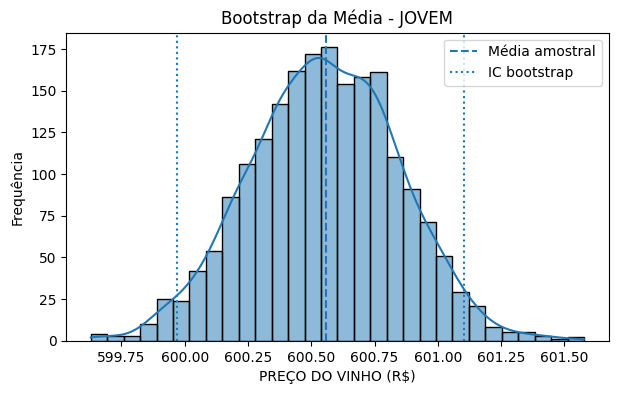


--- RESERVA ---
Tamanho da amostra: 48091
Média: 600.1595
Erro-padrão: 0.4706
IC 95%: (599.2371, 601.0820)


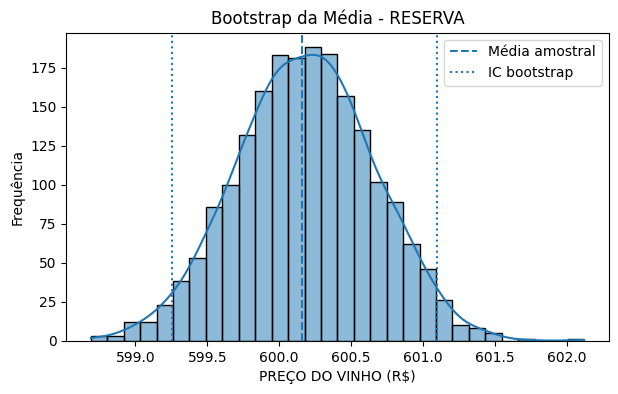


--- GRAN RESERVA ---
Tamanho da amostra: 16052
Média: 601.4924
Erro-padrão: 0.8645
IC 95%: (599.7978, 603.1870)


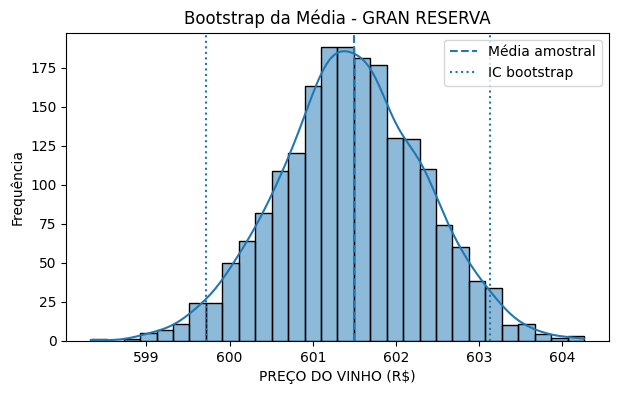


--- RESUMO FINAL ---
         classe       n       media  erro_padrao      IC_inf      IC_sup
0         JOVEM  135857  600.557136     0.286252  599.996087  601.118184
1       RESERVA   48091  600.159518     0.470629  599.237079  601.081958
2  GRAN RESERVA   16052  601.492384     0.864542  599.797786  603.186983


In [ ]:
resultado = analisePrecoVinho(
    table=table,
    yLabel='PREÇO DO VINHO (R$)',
    Qualitativa='CLASSIFICAÇÃO POR TEMPO'
)

In [ ]:
import os

path_exercicios = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'

nome_arquivo = 'atividade3.ipynb'
caminho_entrada = os.path.join(path_exercicios, nome_arquivo)

print(f"A converter: {nome_arquivo}")
print(f"Destino: {path_exercicios}")

!jupyter nbconvert --to html "{caminho_entrada}" --output-dir="{path_exercicios}"

print("\n✅ Concluído! O ficheiro HTML foi gerado diretamente na pasta do Drive.")

A converter: atividade3.ipynb
Destino: /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios
[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade3.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [-